# Neuron sim

In [1]:
from neuron import h
import neuron
import numpy as np
import pandas as pd
from scipy import stats as st
from scipy import signal as ss

import matplotlib.pyplot as plt
import os

neuron.load_mechanisms('mod/')

True

In [2]:

###################### Load and organize Excel file ################################
circuit_params = {}

#Import Excel file
circuit_params = pd.read_excel('Circuit_param.xls', sheet_name = None, index_col = 0)

#Get cell names and import biophys
cell_names = [i for i in circuit_params['conn_probs'].axes[0]]


h.load_file('net_functions.hoc')
for name in cell_names:
    h.load_file('models/biophys_'+name+'.hoc')

In [3]:
# Options
runPlot = 1

durationstim = 6.0
delaystim = 100000.0
timesimulation = 10000.0
ampstim =  [-0.8, -0.6, -0.2, 0.2 ,0.4, 0.6 , 0.8, 1.0]

from cellwrapper import loadCell
cell = loadCell(cell_names[0], 7313766)
soma = cell.soma[0]

stimulus = h.IClamp(0.5, sec=soma)
stimulus.dur = durationstim # ms
stimulus.delay = delaystim  # ms   
step_number=3
stimulus.amp = ampstim[step_number]

bmtkTraces = []
bmtkTracesList = []

recordings = {}

recordings['time'] = h.Vector()
recordings['soma(0.5)'] = h.Vector()

recordings['time'].record(h._ref_t, 0.025)
recordings['soma(0.5)'].record(cell.soma[0](0.5)._ref_v, 0.025)

NeuronTemplate[0]


Vector[1]

In [20]:
cell.axon[0](0.0).diam

2.875

In [4]:
h.v_init = -80.0

In [5]:
h.dt = 0.025
# h.cvode_active(0)
h.tstop = timesimulation # ms
h.run();

Soma voltage for step 3 saved to: soma_voltage_step3.dat


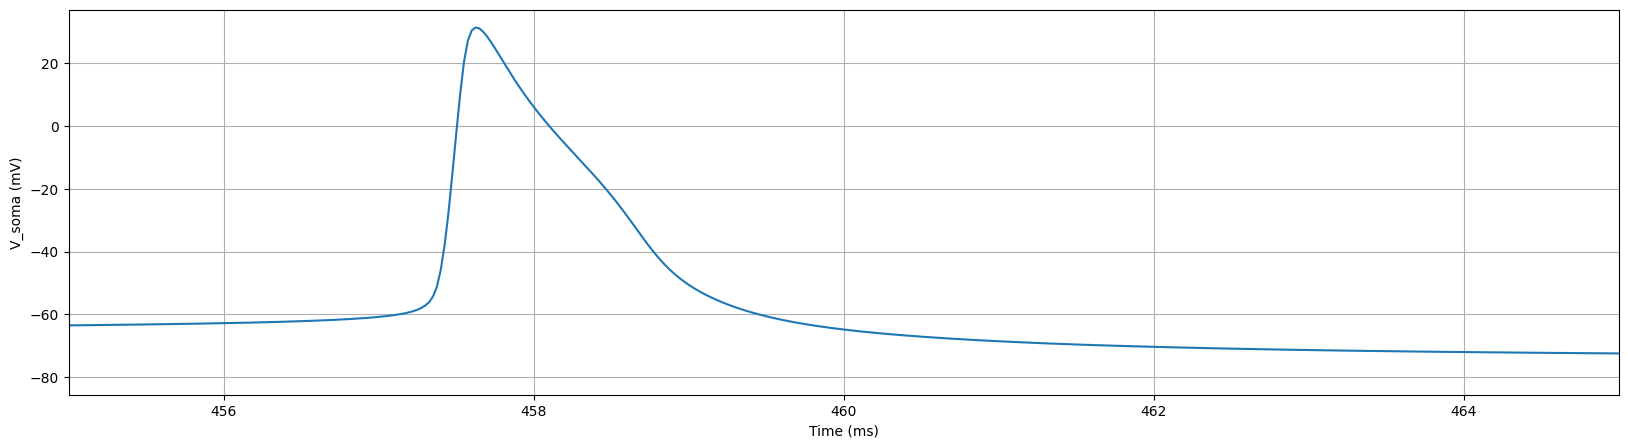

In [6]:

time = np.array(recordings['time'])
soma_voltage = np.array(recordings['soma(0.5)'])

bmtkTraces.append(soma_voltage)
bmtkTracesList.append(list(soma_voltage))

soma_voltage_filename = os.path.join(
    'soma_voltage_step%d.dat' % (step_number))
np.savetxt(soma_voltage_filename, soma_voltage)

print('Soma voltage for step %d saved to: %s'
        % (step_number, soma_voltage_filename))

fig = plt.figure(figsize=(20,5))

plt.plot(time,soma_voltage)
plt.xlabel('Time (ms)')
plt.ylabel('V_soma (mV)')
# plt.xlim(0,6.0)
plt.xlim(455, 465.0)
# plt.ylim(-70,-60)
plt.grid(True)

# fig.savefig('{s1}/{s}_BBP_changingT.png'.format(s1=outFolder,s=folder[cellnumber]))

#  **``LFPy``** rand **``NetPyNE``**

In [7]:
circuit_params['SING_CELL_PARAM']

,HL23PYR,HL23SST,HL23PV,HL23VIP
GOU,0.000028,0.000030,0.000280,0.000066
norm_tonic,0.000938,0.000938,0.000938,0.000938
drug_tonic,0.001352,0.001030,0.001091,0.000938
apic_tonic,0.000938,0.000938,0.000938,0.000938
drug_apic_tonic,0.001352,0.001030,0.001091,0.000938
cell_num,2.000000,2.000000,2.000000,2.000000
rotate_x,3.000000,1.770000,6.000000,-1.570000
rotate_y,4.000000,2.770000,7.000000,3.570000


In [8]:
SPIKES = np.load("Circuit_output/SPIKES_Seed1234.npy", allow_pickle=True)

In [9]:
VOLTAGES = np.load("Circuit_output/VOLTAGES_Seed1234.npy", allow_pickle=True)

In [10]:
import pickle as pkl

with open("Circuit_output/v1_batch1_data.pkl", "rb") as f:
    data = pkl.load(f)

print("Loaded data type:", type(data))
if hasattr(data, "keys"):
    print("Keys:", list(data.keys()))
else:
    print("Data len:", len(data))

Loaded data type: <class 'dict'>
Keys: ['netpyne_version', 'netpyne_changeset', 'net', 'simConfig', 'simData']


In [11]:
data['simData'].keys()

dict_keys(['spkt', 'spkid', 'V_soma', 't', 'popRates', 'avgRate'])

-69.56149584340108 3.1828357405066257
-69.57153038010134 3.187308167173696
-69.56165386323019 3.183086796550804


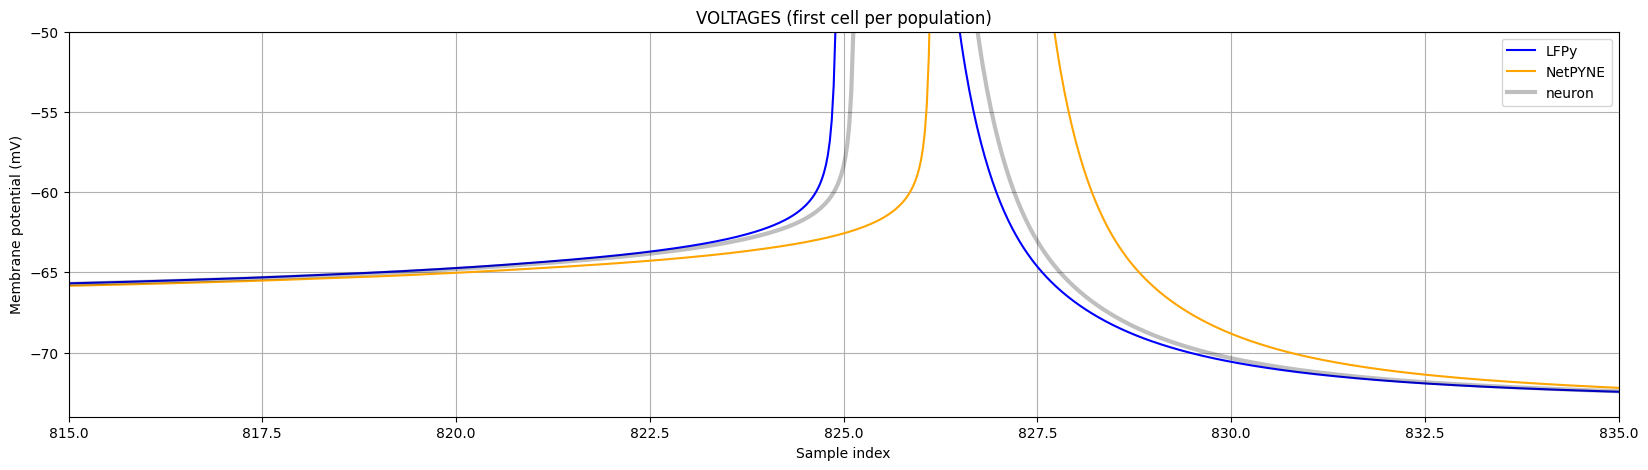

In [12]:
# use existing data (plt already imported)
voltage_data = VOLTAGES.item()['volts']  # list-of-lists by population/cell
pop_names = cell_names  # ['HL23PYR', 'HL23SST', 'HL23PV', 'HL23VIP']

# time axis by sample index (if no explicit dt available)
n_samples = len(voltage_data[0][0])
t = np.arange(0, 10000, 10000/n_samples)

fig, ax = plt.subplots(figsize=(20, 5))
for pop_idx, pop in enumerate(pop_names[0:1]):
    if len(voltage_data[pop_idx]) > 0:
        trace = np.asarray(voltage_data[pop_idx][0])
        print(np.mean(trace), np.std(trace))
        ax.plot(t[: len(trace)], trace, label="LFPy", color='blue')
        # ax.hist(trace, bins=250, alpha=0.5, label='cell_0', color='blue')
        # trace = np.asarray(voltage_data[pop_idx][1])
        # print(np.mean(trace), np.std(trace))
        # ax.hist(trace, bins=250, alpha=0.5, label='cell_0', color='blue')
        # ax.plot(t[: len(trace)], trace, label=pop, color='blue')
        ax.plot(data['simData']['t'], data['simData']['V_soma']['cell_0'], label="NetPYNE", color='orange')
        # ax.plot(data['simData']['t'], data['simData']['V_soma']['cell_1'], label=pop, color='red', alpha=0.5)
        # ax.hist(data['simData']['V_soma']['cell_0'], bins=250, alpha=0.5, label='cell_0', color='orange')
        print(np.mean(data['simData']['V_soma']['cell_0']), np.std(data['simData']['V_soma']['cell_0']))
        # ax.hist(data['simData']['V_soma']['cell_1'], bins=250, alpha=0.5, label='cell_1', color='orange')
        # print(np.mean(data['simData']['V_soma']['cell_1']), np.std(data['simData']['V_soma']['cell_1']))
        ax.plot(time,soma_voltage, label="neuron", color='k', alpha=0.25, linewidth = 3)
        print(np.mean(soma_voltage), np.std(soma_voltage))        

ax.set_xlabel('Sample index')
ax.set_ylabel('Membrane potential (mV)')
ax.set_title('VOLTAGES (first cell per population)')
# ax.set_xlim(4300, 4630.0)
plt.xlim(815, 835.0)
ax.set_ylim(-74, -50)
ax.legend()
plt.grid(True)
plt.show()

-69.56149584340108 3.1828357405066257
-69.57153038010134 3.187308167173696
-69.56165386323019 3.183086796550804


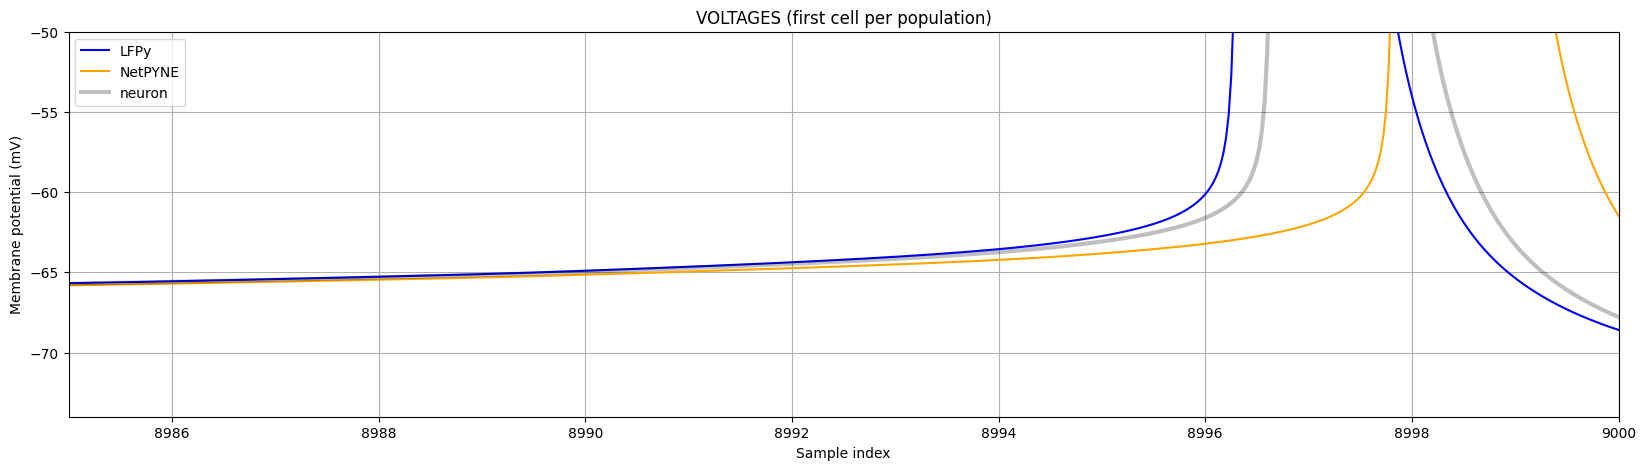

In [13]:
# use existing data (plt already imported)
voltage_data = VOLTAGES.item()['volts']  # list-of-lists by population/cell
pop_names = cell_names  # ['HL23PYR', 'HL23SST', 'HL23PV', 'HL23VIP']

# time axis by sample index (if no explicit dt available)
n_samples = len(voltage_data[0][0])
t = np.arange(0, 10000, 10000/n_samples)

fig, ax = plt.subplots(figsize=(20, 5))
for pop_idx, pop in enumerate(pop_names[0:1]):
    if len(voltage_data[pop_idx]) > 0:
        trace = np.asarray(voltage_data[pop_idx][0])
        print(np.mean(trace), np.std(trace))
        ax.plot(t[: len(trace)], trace, label="LFPy", color='blue')
        # ax.hist(trace, bins=250, alpha=0.5, label='cell_0', color='blue')
        # trace = np.asarray(voltage_data[pop_idx][1])
        # print(np.mean(trace), np.std(trace))
        # ax.hist(trace, bins=250, alpha=0.5, label='cell_0', color='blue')
        # ax.plot(t[: len(trace)], trace, label=pop, color='blue')
        ax.plot(data['simData']['t'], data['simData']['V_soma']['cell_0'], label="NetPYNE", color='orange')
        # ax.plot(data['simData']['t'], data['simData']['V_soma']['cell_1'], label=pop, color='red', alpha=0.5)
        # ax.hist(data['simData']['V_soma']['cell_0'], bins=250, alpha=0.5, label='cell_0', color='orange')
        print(np.mean(data['simData']['V_soma']['cell_0']), np.std(data['simData']['V_soma']['cell_0']))
        # ax.hist(data['simData']['V_soma']['cell_1'], bins=250, alpha=0.5, label='cell_1', color='orange')
        # print(np.mean(data['simData']['V_soma']['cell_1']), np.std(data['simData']['V_soma']['cell_1']))
        ax.plot(time,soma_voltage, label="neuron", color='k', alpha=0.25, linewidth = 3)
        print(np.mean(soma_voltage), np.std(soma_voltage))        

ax.set_xlabel('Sample index')
ax.set_ylabel('Membrane potential (mV)')
ax.set_title('VOLTAGES (first cell per population)')
# ax.set_xlim(4300, 4630.0)
plt.xlim(8985, 9000.0)
ax.set_ylim(-74, -50)
ax.legend()
plt.grid(True)
plt.show()

In [14]:
neuroidx, neuronpeak =  ss.find_peaks(soma_voltage, height=20)
NetPyNEidx, NetPyNEpeak = ss.find_peaks(data['simData']['V_soma']['cell_0'], height=20)
LFPyidx, LFPypeak = ss.find_peaks(trace, height=20)

In [15]:
t[neuroidx]- t[LFPyidx]

array([1.12499719, 0.22499944, 0.02499994, 0.07499981, 0.09999975,
       0.14999963, 0.07499981, 0.07499981, 0.02499994, 0.07499981,
       0.29999925, 0.09999975])

In [16]:
t[NetPyNEidx]- t[LFPyidx]

array([0.77499806, 1.199997  , 0.04999988, 0.04999988, 0.12499969,
       3.27499181, 0.04999988, 0.17499956, 0.02499994, 2.82499294,
       1.47499631, 0.62499844])

In [17]:
LFPypeak['peak_heights'].mean(), neuronpeak['peak_heights'].mean(), NetPyNEpeak['peak_heights'].mean()

(31.348126735355233, 31.383546771974725, 31.381377030245968)

In [18]:
print(len(neuronpeak['peak_heights']), len(NetPyNEpeak['peak_heights']), len(LFPypeak['peak_heights']))

12 12 12


-69.56149584340108 3.1828357405066257
-69.57153038010134 3.187308167173696


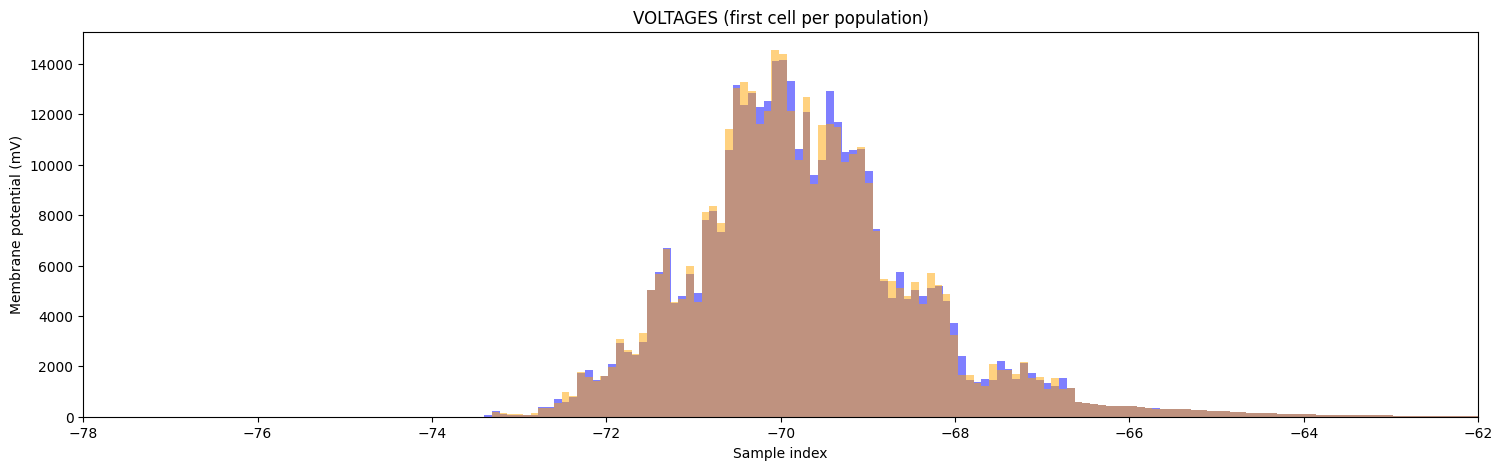

In [19]:
# use existing data (plt already imported)
voltage_data = VOLTAGES.item()['volts']  # list-of-lists by population/cell
pop_names = cell_names  # ['HL23PYR', 'HL23SST', 'HL23PV', 'HL23VIP']

# time axis by sample index (if no explicit dt available)
n_samples = len(voltage_data[0][0])
t = np.arange(0, 10000, 10000/n_samples)

fig, ax = plt.subplots(figsize=(18, 5))
for pop_idx, pop in enumerate(pop_names[0:1]):
    if len(voltage_data[pop_idx]) > 0:
        trace = np.asarray(voltage_data[pop_idx][0])
        print(np.mean(trace), np.std(trace))
        # ax.plot(t[: len(trace)], trace, label=pop, color='blue')
        ax.hist(trace, bins=1250, alpha=0.5, label='cell_0', color='blue')
        # trace = np.asarray(voltage_data[pop_idx][1])
        # print(np.mean(trace), np.std(trace))
        # ax.hist(trace, bins=250, alpha=0.5, label='cell_0', color='blue')
        # ax.plot(t[: len(trace)], trace, label=pop, color='blue')
        # ax.plot(data['simData']['t'], data['simData']['V_soma']['cell_0'], label=pop, color='orange')
        # ax.plot(data['simData']['t'], data['simData']['V_soma']['cell_1'], label=pop, color='orange')
        ax.hist(data['simData']['V_soma']['cell_0'], bins=1250, alpha=0.5, label='cell_0', color='orange')
        print(np.mean(data['simData']['V_soma']['cell_0']), np.std(data['simData']['V_soma']['cell_0']))
        # ax.hist(data['simData']['V_soma']['cell_1'], bins=250, alpha=0.5, label='cell_1', color='orange')
        # print(np.mean(data['simData']['V_soma']['cell_1']), np.std(data['simData']['V_soma']['cell_1']))


ax.set_xlabel('Sample index')
ax.set_ylabel('Membrane potential (mV)')
ax.set_title('VOLTAGES (first cell per population)')
ax.set_xlim(-78., -62)
# ax.set_ylim(-74, -60)
# ax.legend()
plt.show()

In [20]:

def remove_axis_junk(ax, lines=['right', 'top']):
    """remove chosen lines from plotting axis"""
    for loc, spine in ax.spines.items():
        if loc in lines:
            spine.set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

def plot_raster(SPIKES, cell_names):
        tinit = 0
        tend = 10000
        
        colors = ['dimgray', 'crimson', 'green', 'darkorange']
        pop_colors = {'HL23PYR':'dimgray', 'HL23SST':'crimson', 'HL23PV':'green', 'HL23VIP':'darkorange'}
        popnames = ['HL23PYR', 'HL23SST', 'HL23PV', 'HL23VIP']
        # pop_Number = {'HL23PYR': 800, 'HL23SST': 50, 'HL23PV': 70, 'HL23VIP': 80}
        # pop_Number = {'HL23PYR': 2, 'HL23SST': 2, 'HL23PV': 2, 'HL23VIP': 2}
        pop_Number = {'HL23PYR': 10, 'HL23SST': 10, 'HL23PV': 10, 'HL23VIP': 10}
        firing_rate = {}
        # spike raster
        fig, ax = plt.subplots(1, 1, figsize=(8, 4))
        for name, spts, gids in zip(
                cell_names, SPIKES.item()['times'], SPIKES.item()['gids']):
            t = []
            g = []
            for spt, gid in zip(spts, gids):
                t = np.r_[t, spt]
                g = np.r_[g, np.zeros(spt.size) + gid]
            ax.plot(t[(t >= tinit) & (t < tend)], g[(t >= tinit) & (t < tend)], 'o', ms=2, label=name)#, color=pop_colors[name])
            print(name, (len(g[(t >= tinit) & (t < tend)]))/(((tend - tinit)/1000)*pop_Number[name]))
            firing_rate[name] = (len(g[(t >= tinit) & (t < tend)]))/(((tend - tinit)/1000)*pop_Number[name])
        # ax.legend(loc=1)
        # ax.set_ylim(415, -15)
        # ax.set_xlim(tinit + 250, tend - 250)
        # ax.set_xticks([4000, 4500, 5000])
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Cell Number')

        return firing_rate

HL23PYR 0.12
HL23SST 0.0
HL23PV 0.0
HL23VIP 0.0


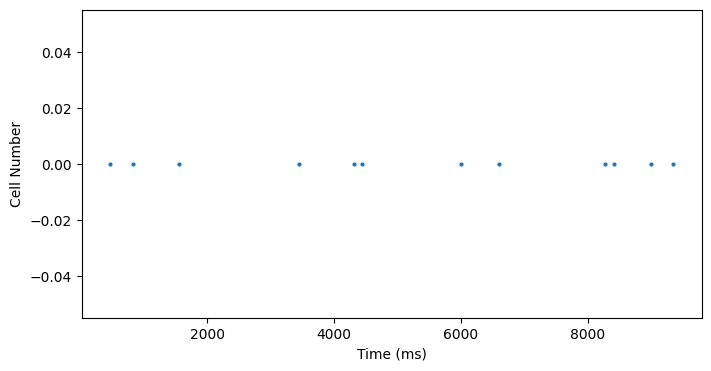

In [21]:
firing_rate = plot_raster(SPIKES, cell_names)

-69.56149584340108 3.1828357405066257
-74.18031291038076 0.21929043310851723
-77.7259058233107 0.3391896744999646
-77.74134922368935 0.29007120446736834
-83.27971917324929 0.5048523884733667
-83.27407997018608 0.5284142003678534
-81.19363839431875 0.35384650123133254
-81.1758822714606 0.42864532559782936


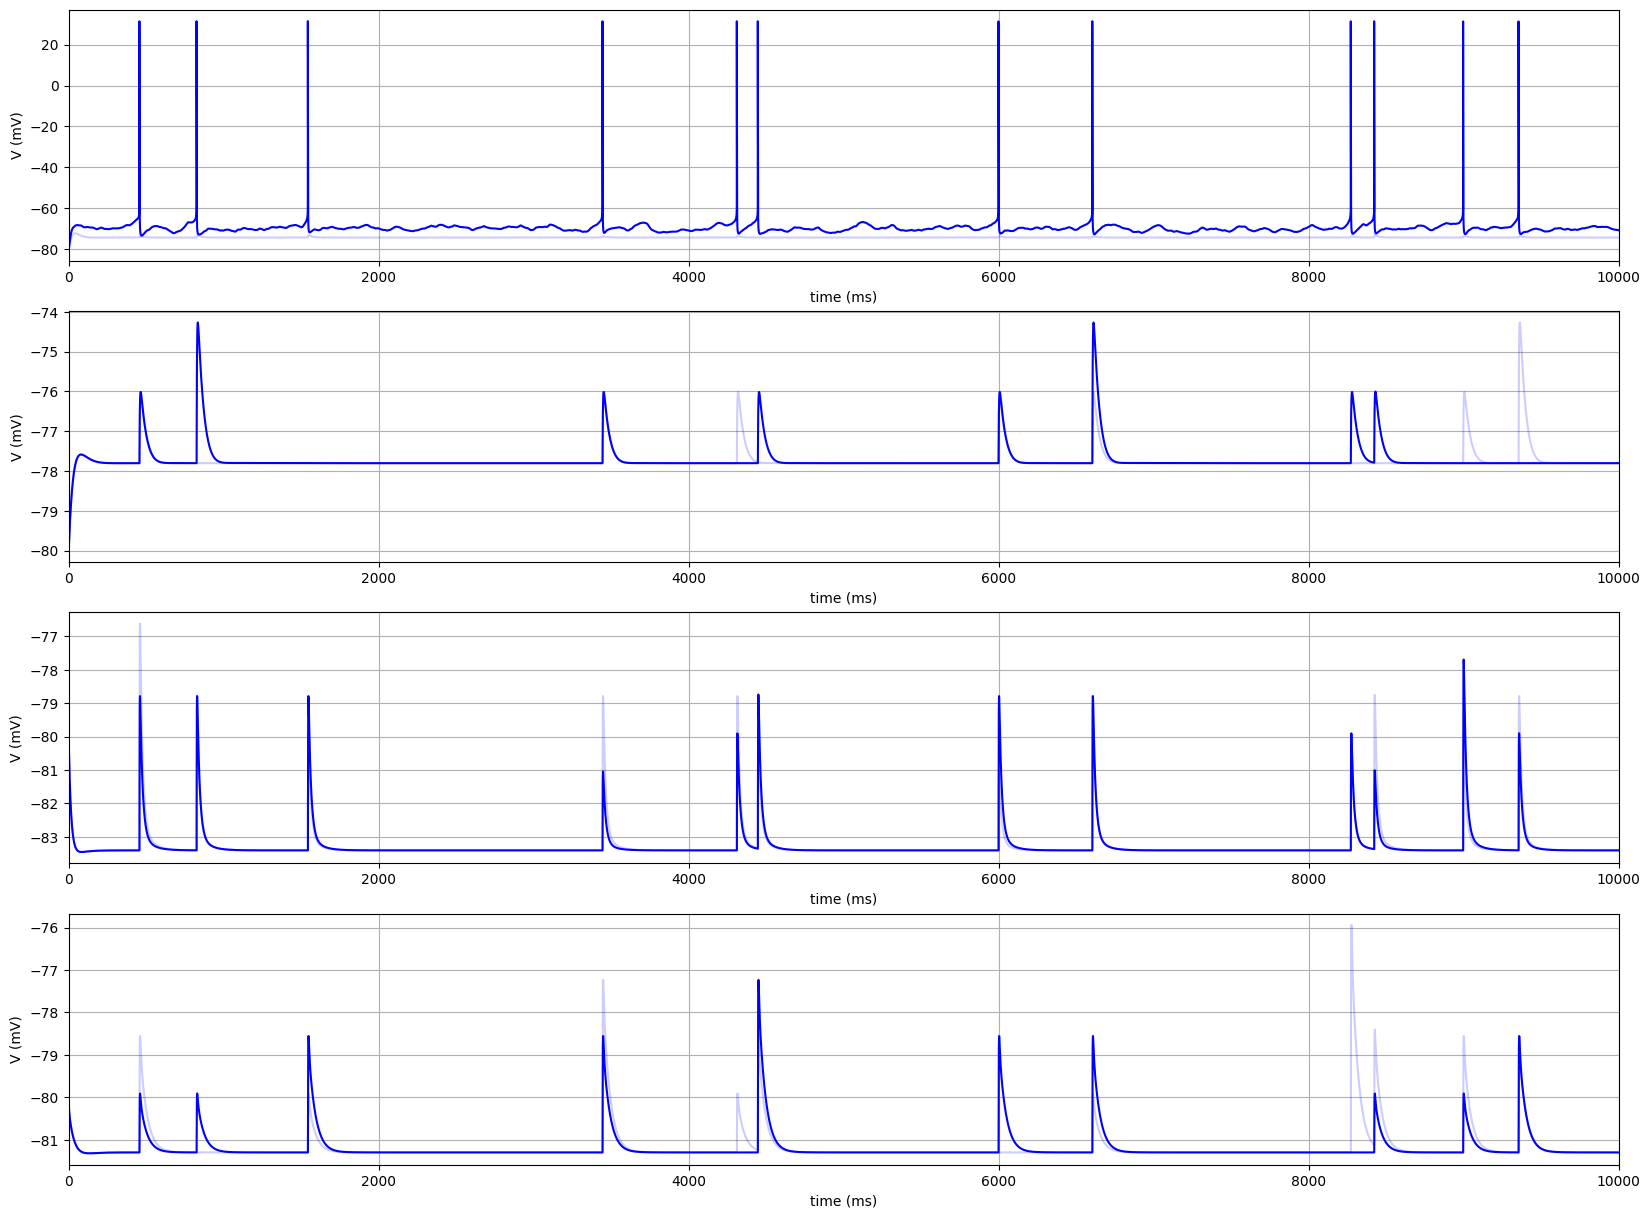

In [22]:
# use existing data (plt already imported)
voltage_data = VOLTAGES.item()['volts']  # list-of-lists by population/cell
pop_names = cell_names  # ['HL23PYR', 'HL23SST', 'HL23PV', 'HL23VIP']

# time axis by sample index (if no explicit dt available)
n_samples = len(voltage_data[0][0])
t = np.arange(0, 10000, 10000/n_samples)

plt.figure(figsize=(20, 15))
ii = 0
for pop_idx, pop in enumerate(pop_names):
    if len(voltage_data[pop_idx]) > 0:
        plt.subplot(4, 1, pop_idx+1)
        for j in range(len(voltage_data[pop_idx])):
            trace = np.asarray(voltage_data[pop_idx][j])
            print(np.mean(trace), np.std(trace))
            plt.plot(t[: len(trace)], trace, label="LFPy", color='blue', alpha=1.0-j*0.8)
            # plt.plot(data['simData']['t'], data['simData']['V_soma']['cell_' + str(ii)], label="NetPYNE", color='orange', alpha=1.0-j*0.8)
            # print(np.mean(data['simData']['V_soma']['cell_' + str(pop_idx)]), np.std(data['simData']['V_soma']['cell_' + str(pop_idx)]))
            plt.grid(True)
            plt.xlabel('time (ms)')
            plt.ylabel('V (mV)')
            plt.xlim(0, 10000.0)
            ii += 1
# plt.ylim(-74, -60)
# plt.legend()
plt.show()